In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

nav = pd.read_csv("data/processed/nav_history_clean.csv")
aum = pd.read_csv("data/generated/aum_by_fund_house.csv")
sip = pd.read_csv("data/generated/monthly_sip.csv")
category = pd.read_csv("data/generated/category_inflows.csv")
transactions = pd.read_csv("data/generated/investor_transactions.csv")
folio = pd.read_csv("data/generated/folio_count.csv")
performance = pd.read_csv("data/generated/scheme_performance.csv")
holdings = pd.read_csv("data/generated/portfolio_holdings.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [20]:
import pandas as pd

In [21]:
nav["date"] = pd.to_datetime(nav["date"])

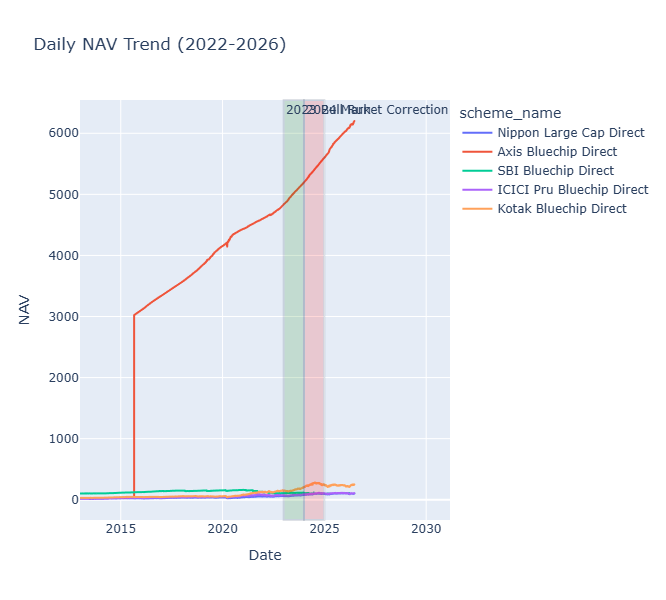

In [22]:
import plotly.express as px

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    height=600
)

fig.show()

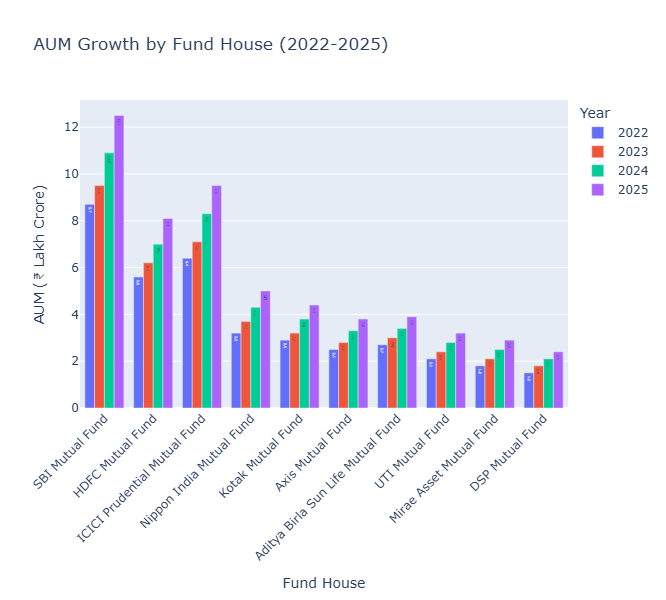

In [23]:
import plotly.express as px

aum_long = aum.melt(
    id_vars="fund_house",
    var_name="Year",
    value_name="AUM"
)

fig = px.bar(
    aum_long,
    x="fund_house",
    y="AUM",
    color="Year",
    barmode="group",
    title="AUM Growth by Fund House (2022-2025)",
    text="AUM"
)

fig.update_layout(
    xaxis_title="Fund House",
    yaxis_title="AUM (₹ Lakh Crore)",
    xaxis_tickangle=-45,
    height=600
)

fig.show()

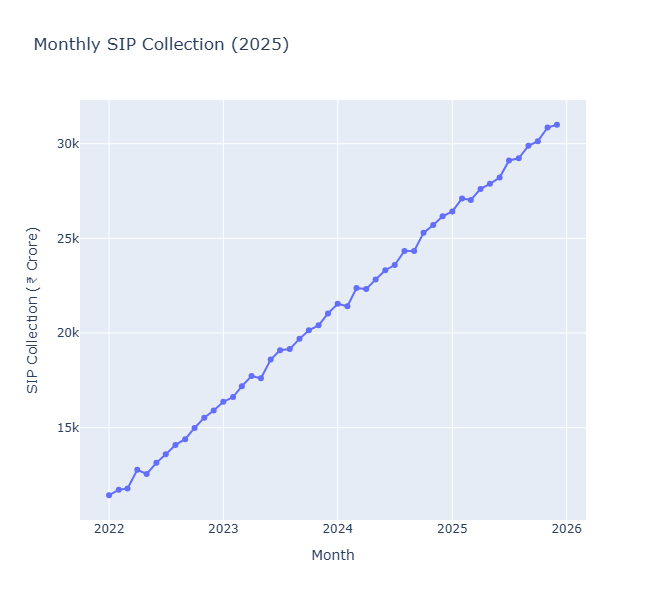

In [24]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_cr",
    title="Monthly SIP Collection (2025)",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Collection (₹ Crore)",
    height=600
)

fig.show()

In [25]:
nav.groupby("scheme_name")["nav"].max()

scheme_name
Axis Bluechip Direct         6200.8511
ICICI Pru Bluechip Direct     113.6849
Kotak Bluechip Direct         281.1083
Nippon Large Cap Direct       106.1272
SBI Bluechip Direct           161.3775
Name: nav, dtype: float64

In [26]:
nav[nav["scheme_name"]=="Axis Bluechip Direct"][["date","nav"]].tail(20)

,date,nav
6875,2026-05-26,6144.0004
6876,2026-05-27,6146.6118
6877,2026-05-29,6151.1139
6878,2026-06-01,6156.7532
6879,2026-06-02,6158.9665
6880,2026-06-03,6159.9626
6881,2026-06-04,6160.9434
6882,2026-06-05,6168.4755
6883,2026-06-08,6174.2084
6884,2026-06-09,6180.6685


In [27]:
raw = pd.read_csv("data/raw/live_nav_119092_Axis_Bluechip_Direct.csv")
raw.tail(20)

,scheme_code,scheme_name,fund_house,scheme_type,scheme_category,date,nav
3561,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-05-26,6144.0004
3562,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-05-27,6146.6118
3563,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-05-29,6151.1139
3564,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-06-01,6156.7532
3565,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-06-02,6158.9665
3566,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-06-03,6159.9626
3567,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-06-04,6160.9434
3568,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-06-05,6168.4755
3569,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-06-08,6174.2084
3570,119092,Axis Bluechip Direct,HDFC Mutual Fund,Open Ended Schemes,Debt Scheme - Money Market Fund,2026-06-09,6180.6685
